In [10]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

import numpy as np
import matplotlib.pyplot as plt
import cv2
import os


c:\Users\Computer\anaconda3\envs\firstenv\lib\site-packages\google\api_core\_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.16) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [11]:
DATASET_DIR = "dataset"
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 10


In [12]:
print("Classes: ", os.listdir(DATASET_DIR))


Classes:  ['ewaste', 'non_ewaste']


(np.float64(-0.5), np.float64(255.5), np.float64(127.5), np.float64(-0.5))

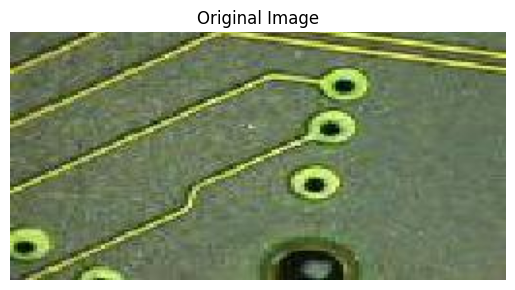

In [13]:
sample_path = DATASET_DIR + "/ewaste/" + os.listdir(DATASET_DIR + "/ewaste")[0]
sample_img = cv2.imread(sample_path)
sample_img_rgb = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)
plt.imshow(sample_img_rgb)
plt.title("Original Image")
plt.axis("off")


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

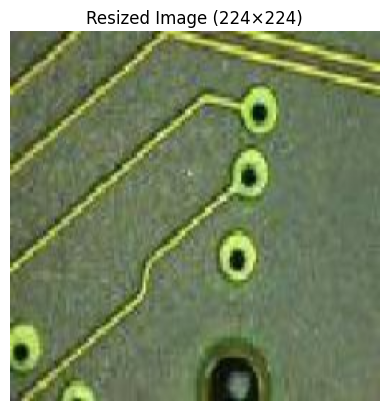

In [14]:
resized_img = cv2.resize(sample_img_rgb, (IMG_SIZE, IMG_SIZE))
plt.imshow(resized_img)
plt.title("Resized Image (224×224)")
plt.axis("off")


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

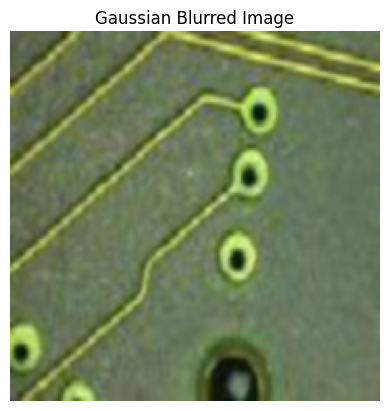

In [15]:
blurred_img = cv2.GaussianBlur(resized_img, (5, 5), 0)
plt.imshow(blurred_img)
plt.title("Gaussian Blurred Image")
plt.axis("off")


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

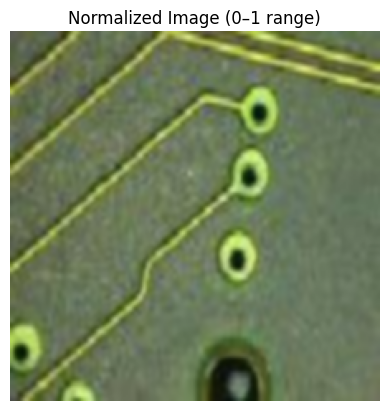

In [16]:
normalized_img = blurred_img / 255.0
plt.imshow(normalized_img)
plt.title("Normalized Image (0–1 range)")
plt.axis("off")


In [17]:
aug_gen = ImageDataGenerator(
    rotation_range=25,
    brightness_range=(0.5, 1.5),
    zoom_range=0.2,
    horizontal_flip=True
)


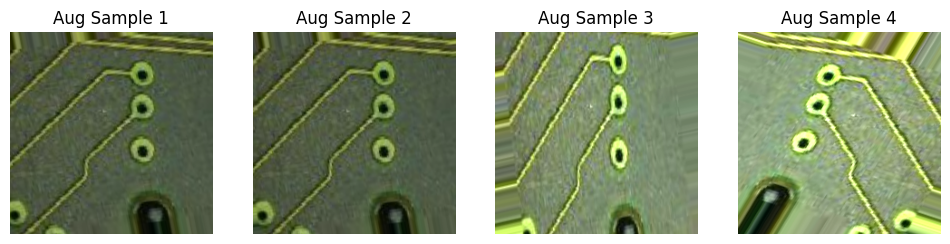

In [18]:
x = np.expand_dims(resized_img, axis=0)

aug_iter = aug_gen.flow(x, batch_size=1)

plt.figure(figsize=(12,4))
for i in range(4):
    batch = next(aug_iter)
    plt.subplot(1,4,i+1)
    plt.imshow(batch[0].astype("uint8"))
    plt.title(f"Aug Sample {i+1}")
    plt.axis("off")


In [19]:
def custom_preprocessing(image):
    image = image.astype("uint8")
    image = cv2.GaussianBlur(image, (5, 5), 0)
    image = image / 255.0
    return image


In [20]:
train_datagen = ImageDataGenerator(
    rotation_range=20,
    brightness_range=(0.7, 1.4),
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2,
    preprocessing_function=custom_preprocessing
)


In [21]:
val_datagen = ImageDataGenerator(
    preprocessing_function=custom_preprocessing,
    validation_split=0.2
)


In [22]:
train_gen = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training"
)

val_gen = val_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation"
)


Found 562 images belonging to 2 classes.
Found 139 images belonging to 2 classes.


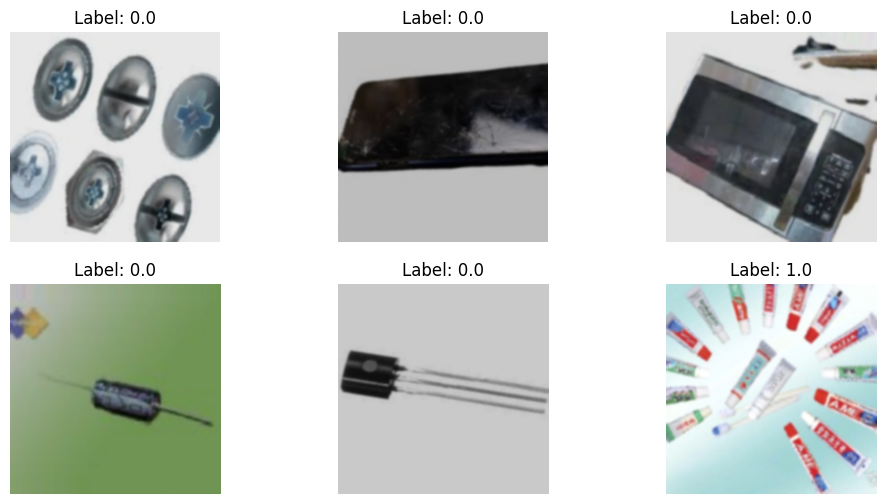

In [23]:
imgs, labels = next(train_gen)

plt.figure(figsize=(12,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(imgs[i])
    plt.title(f"Label: {labels[i]}")
    plt.axis("off")


In [24]:
base_model = tf.keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False


In [25]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)


In [26]:
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [27]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS
)


c:\Users\Computer\anaconda3\envs\firstenv\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.6640 - loss: 0.6724 - val_accuracy: 0.8417 - val_loss: 0.4114
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.8729 - loss: 0.3078 - val_accuracy: 0.8633 - val_loss: 0.3544
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.8937 - loss: 0.2608 - val_accuracy: 0.8777 - val_loss: 0.3547
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.9114 - loss: 0.2283 - val_accuracy: 0.8921 - val_loss: 0.3436
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9351 - loss: 0.1713 - val_accuracy: 0.8058 - val_loss: 0.4979
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.9048 - loss: 0.2249 - val_accuracy: 0.8273 - val_loss: 0.4847
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.9348 - loss: 0.1654 - val_accuracy: 0.8417 - val_loss: 0.4481
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9404 - loss: 0.1463 - val_accuracy: 0.8777 - val_loss:

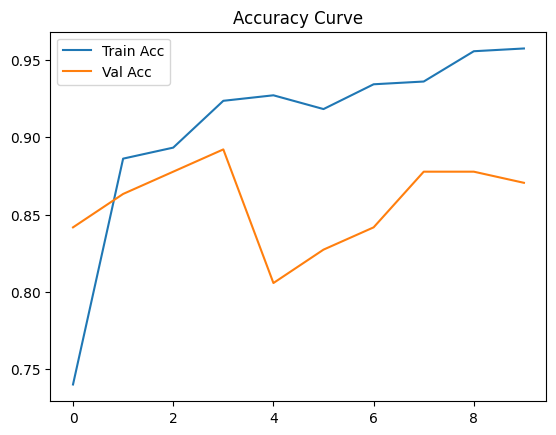

In [28]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy Curve")
plt.legend()
plt.show()


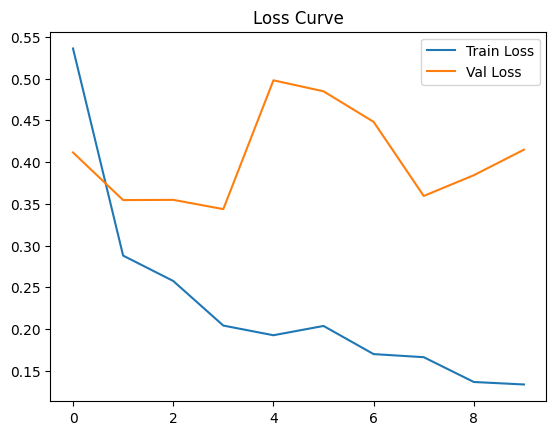

In [29]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Curve")
plt.legend()
plt.show()


In [30]:
model.save("ewaste_classifier.h5")
print("Model saved!")


Model saved!


In [ ]:
def process_for_inference(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = cv2.GaussianBlur(img, (5, 5), 0)
    img = img / 255.0
    img = np.expand_dims(img, axis=0)
    return img


In [ ]:
test_img = process_for_inference(sample_path)
prediction = model.predict(test_img)[0][0]

print("Raw Prediction:", prediction)
print("Class:", "E-Waste" if prediction > 0.5 else "Non E-Waste")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Raw Prediction: 0.8474212
Class: Non E-Waste


(np.float64(-0.5), np.float64(255.5), np.float64(127.5), np.float64(-0.5))

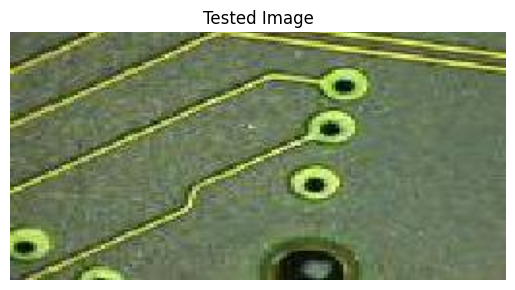

In [37]:
plt.imshow(sample_img_rgb)
plt.title("Tested Image")
plt.axis("off")
